# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

##### *Disini saya menggunakan dataset dari kaggle yaitu Earthquakes 2023 Global, dimana dataset tersebut memiliki 26.642 baris dan 22 kolom. Dataset ini berisi informasi tentang kejadian gempa bumi di seluruh dunia pada tahun 2023.*

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd  # Mengimpor pustaka pandas untuk manipulasi dan analisis data
import numpy as np # Mengimpor pustaka numpy untuk operasi numerik
import seaborn as sns  # Mengimpor pustaka seaborn untuk visualisasi data
import matplotlib.pyplot as plt  # Mengimpor pustaka matplotlib untuk visualisasi grafik

from yellowbrick.cluster import KElbowVisualizer  # Mengimpor KElbowVisualizer untuk visualisasi metode Elbow
from sklearn.decomposition import PCA # Mengimpor PCA untuk reduksi dimensi
from sklearn.preprocessing import MinMaxScaler    # Mengimpor MinMaxScaler untuk standarisasi data
from sklearn.cluster import KMeans  # Mengimpor algoritma KMeans  untuk clustering
from sklearn.metrics import silhouette_score  # Mengimpor silhouette_score untuk mengevaluasi hasil clustering

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [2]:
# Membaca dataset earthquakes tahun 2023 dari kaggle dan menampilkan 5 baris pertama
df = pd.read_csv('earthquakes_2023_global.csv')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2023-01-01T00:49:25.294Z,52.0999,178.5218,82.770,3.10,ml,14.0,139.0,0.8700,0.18,...,2023-03-11T22:51:52.040Z,"Rat Islands, Aleutian Islands, Alaska",earthquake,8.46,21.213,0.097,14.0,reviewed,us,us
1,2023-01-01T01:41:43.755Z,7.1397,126.7380,79.194,4.50,mb,32.0,104.0,1.1520,0.47,...,2023-03-11T22:51:45.040Z,"23 km ESE of Manay, Philippines",earthquake,5.51,7.445,0.083,43.0,reviewed,us,us
2,2023-01-01T03:29:31.070Z,19.1631,-66.5251,24.000,3.93,md,23.0,246.0,0.8479,0.22,...,2023-03-11T22:51:29.040Z,Puerto Rico region,earthquake,0.91,15.950,0.090,16.0,reviewed,pr,pr
3,2023-01-01T04:09:32.814Z,-4.7803,102.7675,63.787,4.30,mb,17.0,187.0,0.4570,0.51,...,2023-03-11T22:51:45.040Z,"99 km SSW of Pagar Alam, Indonesia",earthquake,10.25,6.579,0.238,5.0,reviewed,us,us
4,2023-01-01T04:29:13.793Z,53.3965,-166.9417,10.000,3.00,ml,19.0,190.0,0.4000,0.31,...,2023-03-11T22:51:38.040Z,"59 km SSW of Unalaska, Alaska",earthquake,1.41,1.999,0.085,18.0,reviewed,us,us


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# Menampilkan informasi tentang dataset, termasuk jumlah baris, kolom, tipe data, dan jumlah nilai non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26642 entries, 0 to 26641
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             26642 non-null  object 
 1   latitude         26642 non-null  float64
 2   longitude        26642 non-null  float64
 3   depth            26642 non-null  float64
 4   mag              26642 non-null  float64
 5   magType          26642 non-null  object 
 6   nst              25227 non-null  float64
 7   gap              25225 non-null  float64
 8   dmin             24776 non-null  float64
 9   rms              26642 non-null  float64
 10  net              26642 non-null  object 
 11  id               26642 non-null  object 
 12  updated          26642 non-null  object 
 13  place            25034 non-null  object 
 14  type             26642 non-null  object 
 15  horizontalError  25093 non-null  float64
 16  depthError       26642 non-null  float64
 17  magError    

In [4]:
# Memeriksa jumlah nilai yang hilang di setiap fitur
df.isnull().sum()

time                  0
latitude              0
longitude             0
depth                 0
mag                   0
magType               0
nst                1415
gap                1417
dmin               1866
rms                   0
net                   0
id                    0
updated               0
place              1608
type                  0
horizontalError    1549
depthError            0
magError           1672
magNst             1577
status                0
locationSource        0
magSource             0
dtype: int64

In [5]:
# Menampilkan statistik deskriptif dari dataset untuk fitur numerik
df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,26642.000000,26642.000000,26642.000000,26642.000000,25227.000000,25225.000000,24776.000000,26642.000000,25093.000000,26642.000000,24970.000000,25065.000000
mean,16.852798,-11.487497,67.491224,4.007395,42.571332,124.930971,2.692908,0.581575,7.017267,4.475056,0.122735,33.315939
std,30.389200,130.053399,116.762456,0.794423,37.662352,67.430145,4.043568,0.256276,4.072365,4.451649,0.102271,48.022567
min,-65.849700,-179.998700,-3.370000,2.600000,0.000000,8.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000
25%,-6.415275,-149.608650,10.000000,3.220000,19.000000,73.000000,0.612000,0.410000,4.140000,1.848000,0.080000,10.000000
50%,18.884167,-64.811833,21.998000,4.300000,30.000000,111.000000,1.579000,0.590000,7.060000,2.019000,0.111000,18.000000
75%,41.827950,126.965100,66.833000,4.500000,52.000000,165.000000,3.172000,0.750000,9.730000,6.669000,0.150000,36.000000
max,86.593900,179.999400,681.238000,7.800000,423.000000,350.000000,50.820000,1.880000,99.000000,60.670000,4.490000,884.000000


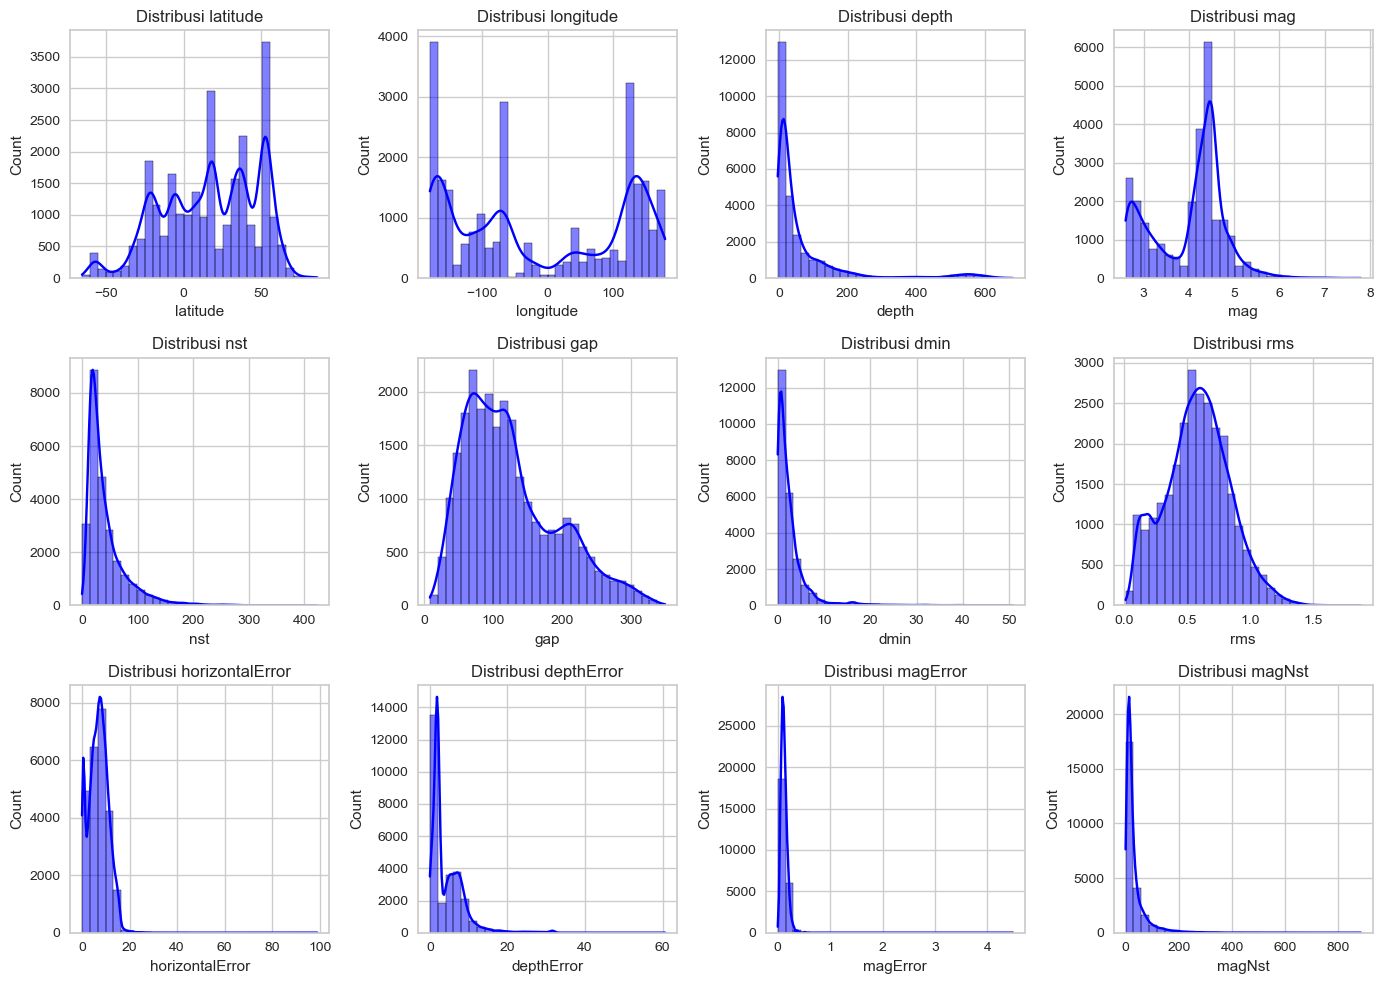

In [6]:
# Distribusi fitur numerik
num_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

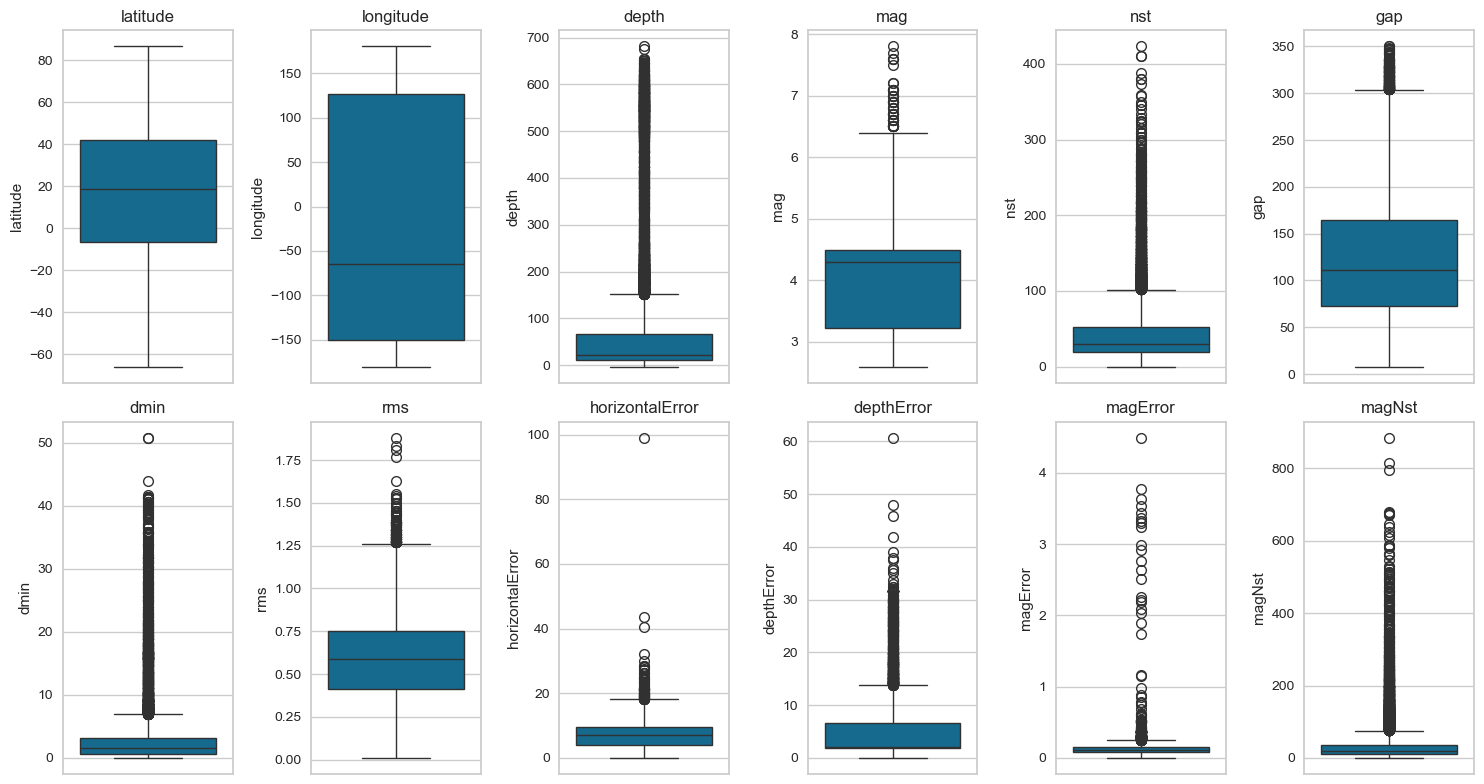

In [7]:
# Mengidentifikasi outlier untuk fitur numerik, namun disini saya tidak menghapusnya karena data tersebut penting.
plt.figure(figsize=(15, 8))
for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 6, i)
    sns.boxplot(y=df[feature]) 
    plt.title(feature) 
plt.tight_layout()
plt.show()

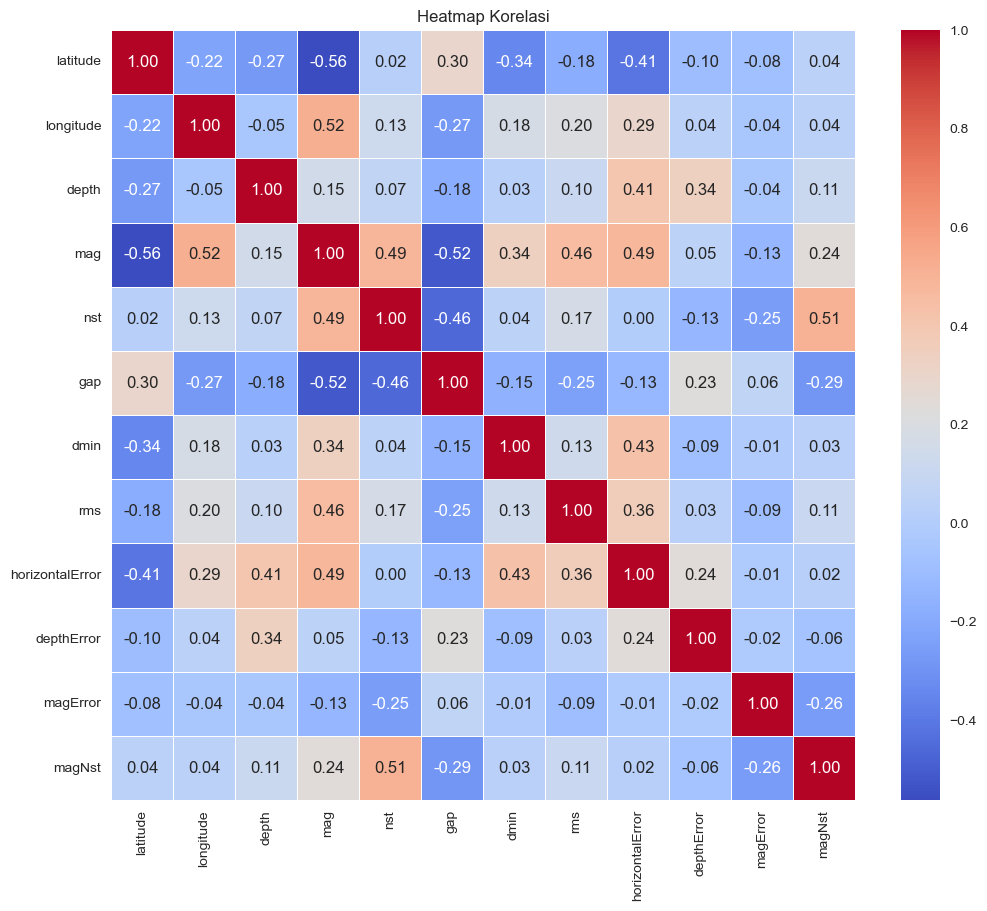

In [8]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

In [9]:
# Menampilkan statistik deskriptif dari dataset untuk fitur kategorikal
df.describe(include='object')

,time,magType,net,id,updated,place,type,status,locationSource,magSource
count,26642,26642,26642,26642,26642,25034,26642,26642,26642,26642
unique,24682,15,15,24682,7847,14811,8,2,16,19
top,2023-04-06T01:08:20.773Z,mb,us,us6000k40m,2023-10-17T22:01:29.040Z,"Izu Islands, Japan region",earthquake,reviewed,us,us
freq,2,15906,21411,2,97,358,26428,26566,21409,21249


C:\Users\septi\AppData\Local\Temp\ipykernel_9908\2007692567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[feature], order=df[feature].value_counts().index, palette='viridis')
C:\Users\septi\AppData\Local\Temp\ipykernel_9908\2007692567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[feature], order=df[feature].value_counts().index, palette='viridis')
C:\Users\septi\AppData\Local\Temp\ipykernel_9908\2007692567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[feature], order=df[feature].value_counts().index, pa

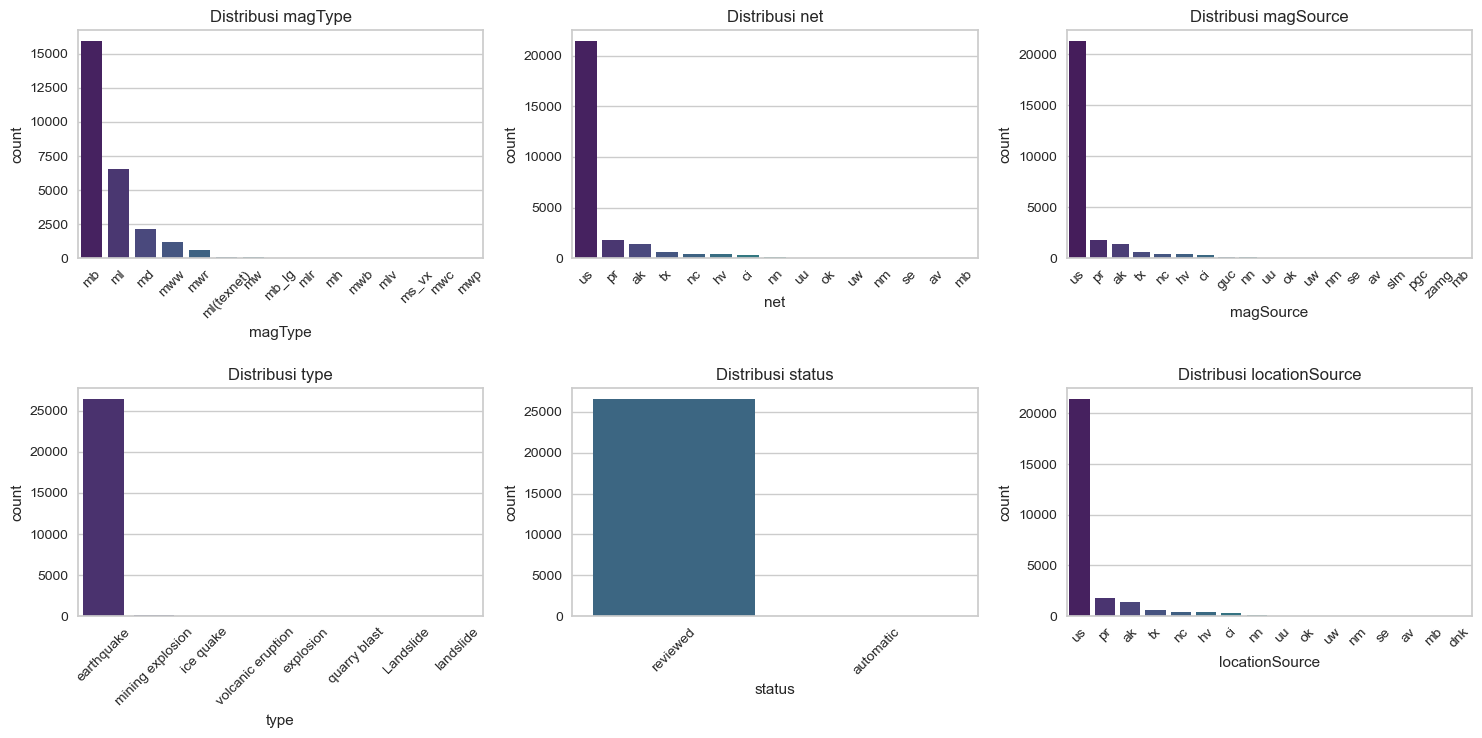

In [10]:
# Distribusi fitur kategorikal
cat_features = ['magType', 'net', 'magSource', 'type', 'status', 'locationSource']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(cat_features, 1):
    plt.subplot(3, 3, i) 
    sns.countplot(x=df[feature], order=df[feature].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {feature}')
    plt.xticks(rotation=45)  
plt.tight_layout() 
plt.show()

C:\Users\septi\AppData\Local\Temp\ipykernel_9908\4075425978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')


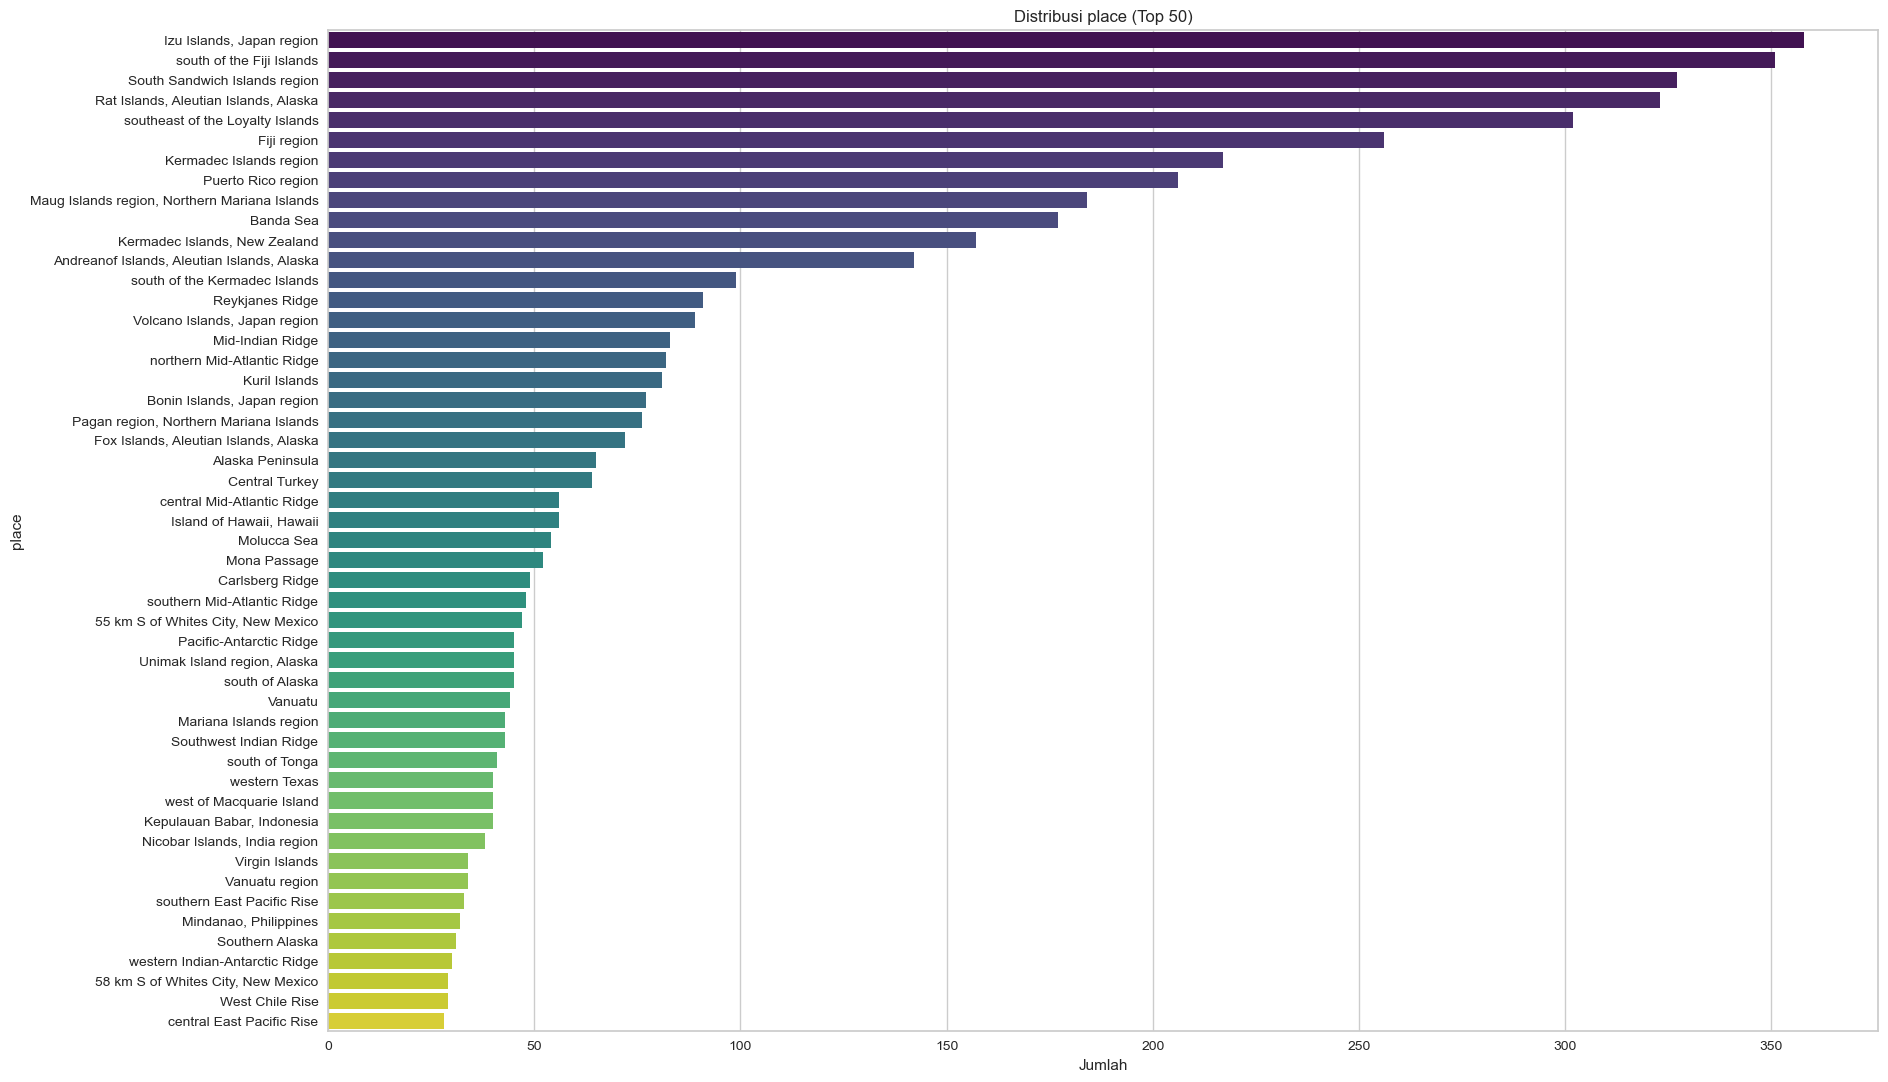

In [11]:
# Distribusi fitur kategorikal (place)
cat_features = ['place']
for feature in cat_features:
    plt.figure(figsize=(20, 13)) 
    top_values = df[feature].value_counts().nlargest(50)  # Ambil 50 kategori terbanyak
    sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')  
    plt.title(f'Distribusi {feature} (Top 50)')
    plt.xlabel("Jumlah")
    plt.ylabel(feature)
    plt.show()

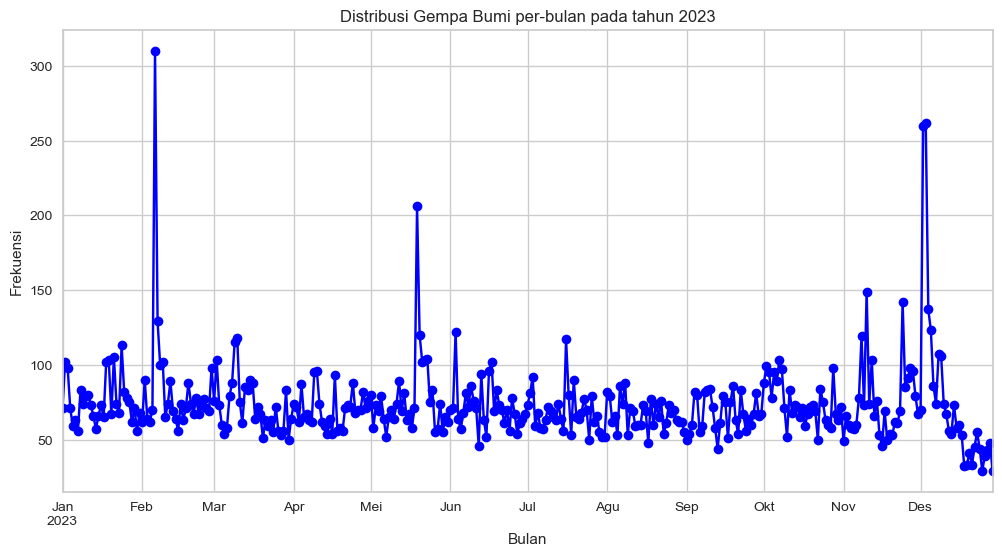

In [12]:
# Konversi kolom time ke tipe datetime dan ekstrak bulan
df['time'] = pd.to_datetime(df['time'])

# Plot distribusi gempa per bulan
jumlah = df.resample('D', on='time').size()
plt.figure(figsize=(12, 6))
jumlah.plot(kind='line', color='Blue', marker='o')
plt.title('Distribusi Gempa Bumi per-bulan pada tahun 2023')
plt.xlabel('Bulan')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.show()

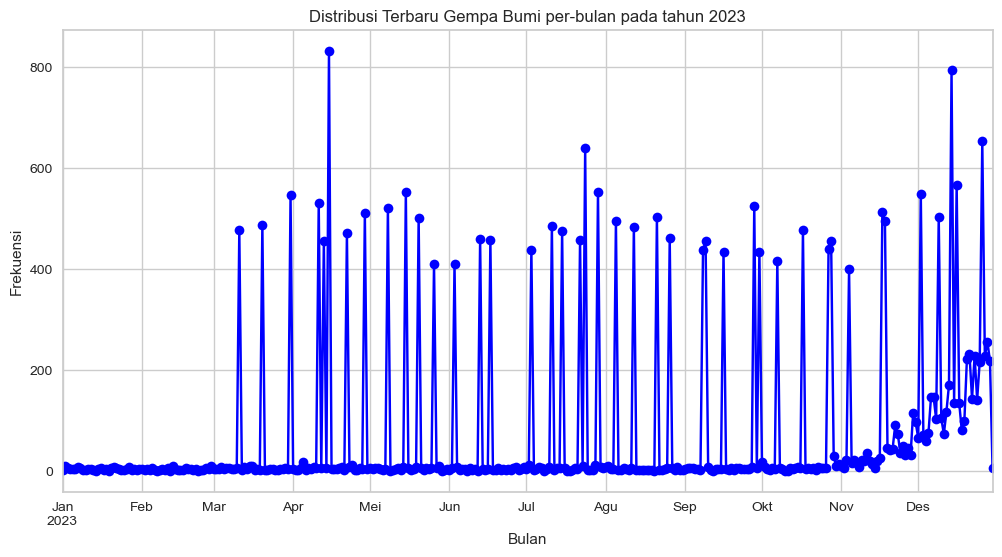

In [13]:
# Konversi kolom updated ke tipe datetime dan ekstrak bulan
df['updated'] = pd.to_datetime(df['updated'])

# Plot distribusi gempa per bulan
jumlah = df.resample('D', on='updated').size()
plt.figure(figsize=(12, 6))
jumlah.plot(kind='line', color='Blue', marker='o')
plt.title('Distribusi Terbaru Gempa Bumi per-bulan pada tahun 2023')
plt.xlabel('Bulan')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.show()

In [14]:
# Mengidentifikasi duplikat data
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  1960


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [15]:
# Membuat salinan dari DataFrame untuk membersihkan data
clean_df = df.copy()

# Menghapus kolom yang tidak diperlukan
kolom_hapus = ['time', 'updated', 'place', 'id', # karena terlalu banyak variasi data
               'type', 'status', # karena terlalu sedikit variasi data
               'locationSource', 'magSource' # variasi data sama dengan net
               ]
clean_df = clean_df.drop(columns=kolom_hapus)

# testing
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26642 entries, 0 to 26641
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   latitude         26642 non-null  float64
 1   longitude        26642 non-null  float64
 2   depth            26642 non-null  float64
 3   mag              26642 non-null  float64
 4   magType          26642 non-null  object 
 5   nst              25227 non-null  float64
 6   gap              25225 non-null  float64
 7   dmin             24776 non-null  float64
 8   rms              26642 non-null  float64
 9   net              26642 non-null  object 
 10  horizontalError  25093 non-null  float64
 11  depthError       26642 non-null  float64
 12  magError         24970 non-null  float64
 13  magNst           25065 non-null  float64
dtypes: float64(12), object(2)
memory usage: 2.8+ MB


In [16]:
# Menghapus Data Duplikat
clean_df = clean_df.drop_duplicates()

# testing
print("Jumlah duplikasi: ", clean_df.duplicated().sum())

Jumlah duplikasi:  0


In [17]:
# Menghitung jumlah nilai yang hilang di setiap kolom pada clean_df
missing = clean_df.isnull().sum()

# Memisahkan kolom yang memiliki missing value lebih dari 75% dan kurang dari 75%
less_missing = missing[missing < 1500].index
more_missing = missing[missing >= 1500].index

# Isi yang kurang dari 1500
for col in less_missing:
    if clean_df[col].dtype == 'object':
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])
    else:
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Menghapus kolom dengan terlalu banyak nilai yang hilang
clean_df = clean_df.drop(columns=more_missing) 

# testing
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24682 entries, 0 to 26641
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    24682 non-null  float64
 1   longitude   24682 non-null  float64
 2   depth       24682 non-null  float64
 3   mag         24682 non-null  float64
 4   magType     24682 non-null  object 
 5   nst         24682 non-null  float64
 6   gap         24682 non-null  float64
 7   rms         24682 non-null  float64
 8   net         24682 non-null  object 
 9   depthError  24682 non-null  float64
dtypes: float64(8), object(2)
memory usage: 2.1+ MB


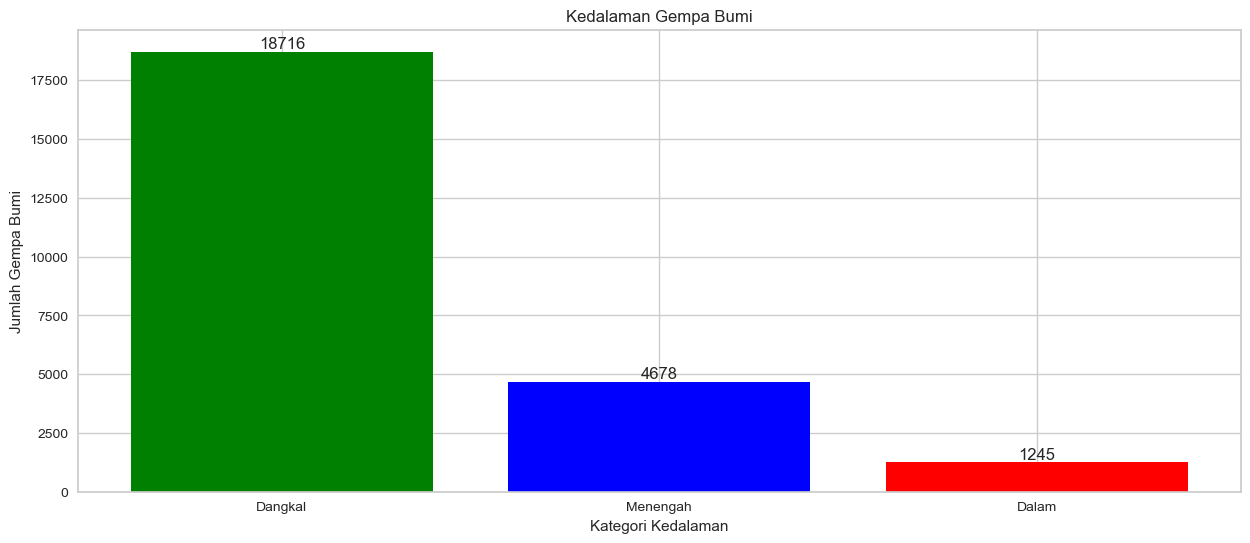

In [18]:
# Mengelompokkan kedalaman(depth) ke dalam kategori dan menghitung jumlah gempa bumi di setiap kategori
Dangkal = clean_df.depth[(clean_df.depth >= 0) & (clean_df.depth <= 70)]
Menengah = clean_df.depth[(clean_df.depth > 70) & (clean_df.depth <= 300)]
Dalam = clean_df.depth[clean_df.depth > 300]

# Menyusun data untuk plotting
x = ["Dangkal", "Menengah", "Dalam"]
y = [len(Dangkal.values), len(Menengah.values), len(Dalam.values)]

# Membuat bar chart untuk distribusi kedalaman gempa bumi
plt.figure(figsize=(15, 6))
plt.bar(x, y, color=['green', 'blue', 'red'])  
plt.title("Kedalaman Gempa Bumi")
plt.xlabel("Kategori Kedalaman")
plt.ylabel("Jumlah Gempa Bumi")

# Menambahkan label jumlah gempa bumi di atas setiap bar
for i in range(len(x)):
  plt.text(i, y[i], y[i], ha='center', va='bottom')

plt.show()

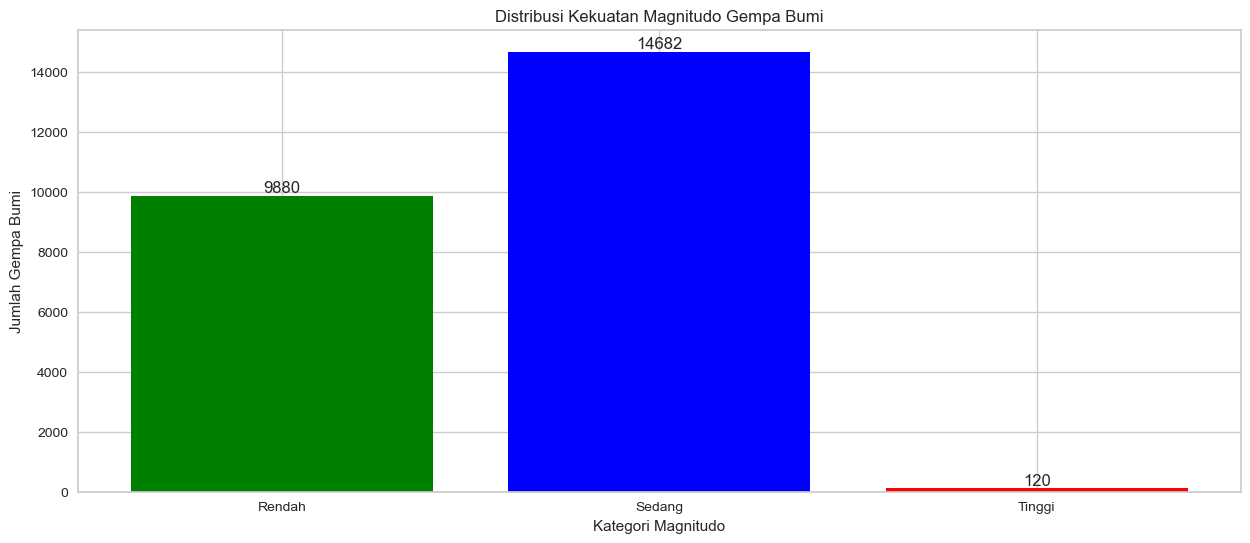

In [19]:
# Mengelompokkan magnitudo (mag) ke dalam kategori
Rendah = clean_df.mag[(clean_df.mag >= 0) & (clean_df.mag <= 4)]
Sedang = clean_df.mag[(clean_df.mag > 4) & (clean_df.mag <= 6)]
Tinggi = clean_df.mag[clean_df.mag > 6]

# Menyusun data untuk plotting
x_mag = ["Rendah", "Sedang", "Tinggi"]
y_mag = [len(Rendah.values), len(Sedang.values), len(Tinggi.values)]

# Membuat bar chart untuk distribusi kekuatan magnitudo
plt.figure(figsize=(15, 6))
plt.bar(x_mag, y_mag, color=['green', 'blue', 'red'])
plt.title("Distribusi Kekuatan Magnitudo Gempa Bumi")
plt.xlabel("Kategori Magnitudo")
plt.ylabel("Jumlah Gempa Bumi")

# Menambahkan label jumlah gempa bumi di atas setiap bar
for i in range(len(x_mag)):
    plt.text(i, y_mag[i], y_mag[i], ha='center', va='bottom')

plt.show()

In [20]:
# Mengubah data kategorikal menjadi numerik menggunakan OneHotEncoder
cat_features = clean_df.select_dtypes(include=['object']).columns

# Menggunakan pd.get_dummies untuk One-Hot Encoding menggunakan dataframe yg sudah discaled
df_encoded  = pd.get_dummies(clean_df, columns=cat_features)

# Konversi boolean menjadi numerik (0 dan 1)
df_encoded = df_encoded.astype(int)

# Menampilkan hasil
df_encoded 

,latitude,longitude,depth,mag,nst,gap,rms,depthError,magType_mb,magType_mb_lg,...,net_nc,net_nm,net_nn,net_ok,net_pr,net_se,net_tx,net_us,net_uu,net_uw
0,52,178,82,3,14,139,0,21,0,0,...,0,0,0,0,0,0,0,1,0,0
1,7,126,79,4,32,104,0,7,1,0,...,0,0,0,0,0,0,0,1,0,0
2,19,-66,24,3,23,246,0,15,0,0,...,0,0,0,0,1,0,0,0,0,0
3,-4,102,63,4,17,187,0,6,1,0,...,0,0,0,0,0,0,0,1,0,0
4,53,-166,10,3,19,190,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26637,-6,154,10,5,72,60,0,1,1,0,...,0,0,0,0,0,0,0,1,0,0
26638,32,141,10,5,74,121,0,1,1,0,...,0,0,0,0,0,0,0,1,0,0
26639,-7,68,10,5,60,54,0,1,1,0,...,0,0,0,0,0,0,0,1,0,0
26640,-19,169,153,4,40,61,0,7,1,0,...,0,0,0,0,0,0,0,1,0,0


In [21]:
# Normalisasi fitur numerik
num_features = clean_df.select_dtypes(include=['number']).columns
scaler = MinMaxScaler()
df_normalized = df_encoded.copy()  # Simpan salinan
df_normalized[num_features] = scaler.fit_transform(clean_df[num_features]) 
  
# testing
df_normalized.describe()

,latitude,longitude,depth,mag,nst,gap,rms,depthError,magType_mb,magType_mb_lg,...,net_nc,net_nm,net_nn,net_ok,net_pr,net_se,net_tx,net_us,net_uu,net_uw
count,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,...,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000,24682.000000
mean,0.550043,0.456466,0.102609,0.263130,0.098562,0.344544,0.301380,0.073863,0.568471,0.002431,...,0.017543,0.000608,0.003646,0.001742,0.073130,0.000284,0.023539,0.788388,0.001823,0.001540
std,0.198847,0.360891,0.169204,0.156282,0.088377,0.196220,0.137737,0.075088,0.495300,0.049245,...,0.131286,0.024645,0.060276,0.041704,0.260355,0.016839,0.151612,0.408459,0.042661,0.039208
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.393133,0.080589,0.019529,0.111538,0.044917,0.195906,0.208556,0.030328,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.557735,0.316206,0.037058,0.307692,0.068558,0.304094,0.304813,0.033245,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.719351,0.852290,0.101818,0.365385,0.118203,0.459064,0.390374,0.109820,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

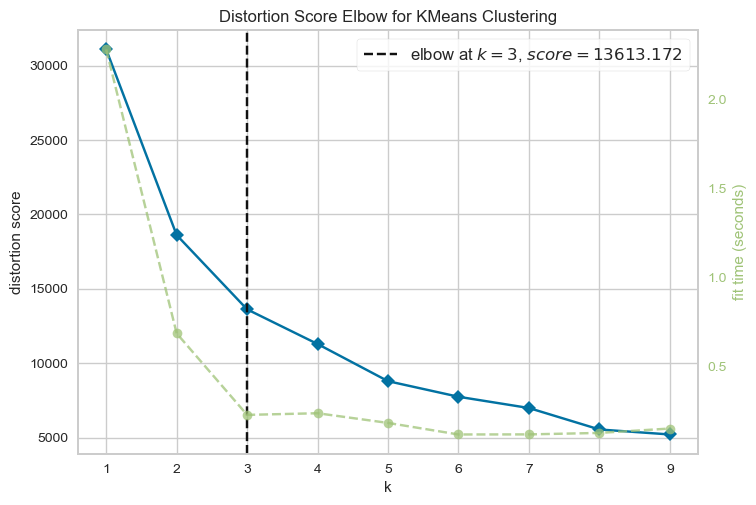

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [22]:
# karena menggunakan K-Means maka akan menentukan jumlah cluster optimal dengan metode Elbow 
# Inisialisasi model KMeans  menggunakan parameter random_state untuk memastikan hasil yang konsisten
kmeans = KMeans(random_state=42)
 
# Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(1, 10))
 
# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer.fit(df_normalized)
 
# Menampilkan grafik elbow untuk analisis
visualizer.show()

In [23]:
# Inisialisasi model dengan k=3 (dari hasil elbow)
kmeans_3 = KMeans(n_clusters=3, random_state=42)

# Melatih model dengan data yang sudah di-encode dan distandarisasi
kmeans_3.fit(df_normalized)

KMeans(n_clusters=3, random_state=42)

In [24]:
# Inisialisasi model dengan k=5 
kmeans_5 = KMeans(n_clusters=5, random_state=42)

# Melatih model dengan data yang sudah di-encode dan distandarisasi
kmeans_5.fit(df_normalized)

KMeans(n_clusters=5, random_state=42)

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

In [25]:
# Hitung silhouette score dari k=3
sil_score = silhouette_score(df_normalized, kmeans_3.labels_)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.5285


In [26]:
# Hitung silhouette score dari k=5
sil_score = silhouette_score(df_normalized, kmeans_5.labels_)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.5608


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [27]:
# Menyeleksi fitur
cols_to_drop = ['nst', 'gap', 'rms', 'depthError'] + [col for col in df_normalized.columns if col.startswith('net_')]
feature_select = df_normalized.drop(columns=cols_to_drop)

# testing fitur yang dipilih
feature_select.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24682 entries, 0 to 26641
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   latitude            24682 non-null  float64
 1   longitude           24682 non-null  float64
 2   depth               24682 non-null  float64
 3   mag                 24682 non-null  float64
 4   magType_mb          24682 non-null  int32  
 5   magType_mb_lg       24682 non-null  int32  
 6   magType_md          24682 non-null  int32  
 7   magType_mh          24682 non-null  int32  
 8   magType_ml          24682 non-null  int32  
 9   magType_ml(texnet)  24682 non-null  int32  
 10  magType_mlr         24682 non-null  int32  
 11  magType_mlv         24682 non-null  int32  
 12  magType_ms_vx       24682 non-null  int32  
 13  magType_mw          24682 non-null  int32  
 14  magType_mwb         24682 non-null  int32  
 15  magType_mwc         24682 non-null  int32  
 16  magType_m

In [28]:
# Menggunakan PCA untuk fiture selection
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(feature_select)

In [29]:
# Inisialisasi ulang dan latih model KMeans
pca_kmeans = KMeans(n_clusters=3, random_state=42)  
pca_kmeans.fit(reduced_data)

KMeans(n_clusters=3, random_state=42)

In [30]:
# Membuat DataFrame baru dengan hasil PCA dan label kluster
reduced_df = pd.DataFrame(reduced_data, columns=['PCA1', 'PCA2'])
reduced_df['cluster'] = pca_kmeans.labels_  
reduced_df.head()

,PCA1,PCA2,cluster
0,-0.674716,-0.229977,1
1,0.629323,-0.086192,0
2,-0.361366,0.987253,2
3,0.610784,-0.082320,0
4,-1.035067,-0.267102,1


In [31]:
# Rasio varians yang dijelaskan oleh komponen
print(pca.explained_variance_ratio_)

[0.55423304 0.15316313]


In [32]:
# Hitung silhouette score dengan data yang sudah direduksi
sil_score = silhouette_score(reduced_data, pca_kmeans.labels_)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.8613


Dengan menggunakan PCA Silhouette Score meningkat dari 0.5 menjadi 0.8

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

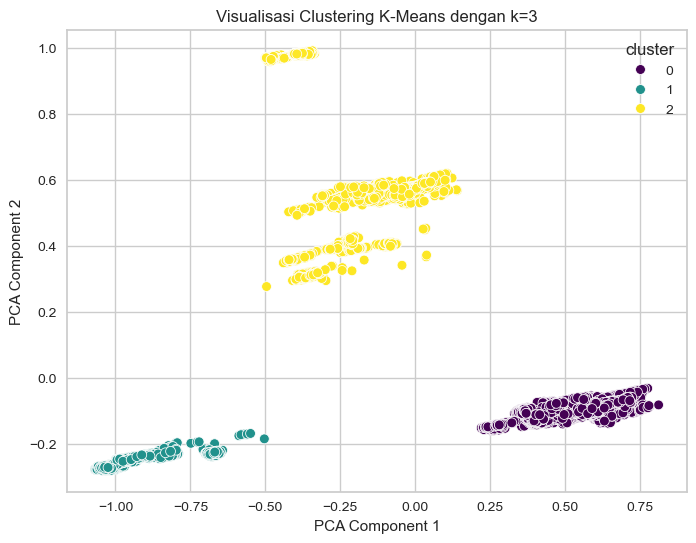

In [33]:
# Visualisasi hasil clustering menggunakan pca

plt.figure(figsize=(8, 6))
sns.scatterplot(data=reduced_df, x='PCA1', y='PCA2', hue='cluster', palette="viridis", s=50)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Visualisasi Clustering K-Means dengan k=3")
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [34]:
# Menggabungkan hasil cluster dalam dataframe baru yang sudah dinormalisasi
df_cluster = feature_select.copy()  
df_cluster['cluster'] = pca_kmeans.labels_  # Menambahkan label cluster setelah pca ke dataframe
df_cluster.info()
df_cluster.head()

<class 'pandas.core.frame.DataFrame'>
Index: 24682 entries, 0 to 26641
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   latitude            24682 non-null  float64
 1   longitude           24682 non-null  float64
 2   depth               24682 non-null  float64
 3   mag                 24682 non-null  float64
 4   magType_mb          24682 non-null  int32  
 5   magType_mb_lg       24682 non-null  int32  
 6   magType_md          24682 non-null  int32  
 7   magType_mh          24682 non-null  int32  
 8   magType_ml          24682 non-null  int32  
 9   magType_ml(texnet)  24682 non-null  int32  
 10  magType_mlr         24682 non-null  int32  
 11  magType_mlv         24682 non-null  int32  
 12  magType_ms_vx       24682 non-null  int32  
 13  magType_mw          24682 non-null  int32  
 14  magType_mwb         24682 non-null  int32  
 15  magType_mwc         24682 non-null  int32  
 16  magType_m

,latitude,longitude,depth,mag,magType_mb,magType_mb_lg,magType_md,magType_mh,magType_ml,magType_ml(texnet),magType_mlr,magType_mlv,magType_ms_vx,magType_mw,magType_mwb,magType_mwc,magType_mwp,magType_mwr,magType_mww,cluster
0,0.773726,0.995896,0.125824,0.096154,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
1,0.478796,0.852051,0.120600,0.365385,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0.557667,0.315206,0.039979,0.255769,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2
3,0.400603,0.785466,0.098096,0.326923,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0.782232,0.036270,0.019529,0.076923,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [35]:
# Ambil kolom one-hot langsung dari df_cluster
magtype_cols = [col for col in df_cluster.columns if col.startswith('magType_')]

# Inverse one-hot encoding
if magtype_cols:
    df_cluster['magType'] = df_cluster[magtype_cols].idxmax(axis=1).str.replace('magType_', '', regex=False)
    df_cluster.drop(columns=magtype_cols, inplace=True) # Menghapus kolom one-hot yang sudah tidak diperlukan
else:
    print("Kolom magType_* tidak ditemukan di df_cluster.")

# Cek hasil
print(df_cluster['magType'].value_counts())

magType
mb            14031
ml             6520
md             2117
mww            1185
mwr             534
ml(texnet)      134
mw               86
mb_lg            60
mlr               4
mh                3
mwb               3
mlv               2
ms_vx             1
mwc               1
mwp               1
Name: count, dtype: int64


In [40]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24682 entries, 0 to 26641
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   24682 non-null  float64
 1   longitude  24682 non-null  float64
 2   depth      24682 non-null  float64
 3   mag        24682 non-null  float64
 4   cluster    24682 non-null  int32  
 5   magType    24682 non-null  object 
dtypes: float64(4), int32(1), object(1)
memory usage: 1.2+ MB


In [48]:
# Inisialisasi dan fit ulang scaler dengan kolom numerik yang sekarang
scaler_new = MinMaxScaler()
scaler_new.fit(clean_df[['latitude', 'longitude', 'depth', 'mag']])

# Inverse transform ke data hasil cluster
df_cluster[['latitude', 'longitude', 'depth', 'mag']] = scaler_new.inverse_transform(
    df_cluster[['latitude', 'longitude', 'depth', 'mag']]
)

# testing
df_cluster

,latitude,longitude,depth,mag,cluster,magType
0,52.0999,178.5218,82.770,3.10,1,ml
1,7.1397,126.7380,79.194,4.50,0,mb
2,19.1631,-66.5251,24.000,3.93,2,md
3,-4.7803,102.7675,63.787,4.30,0,mb
4,53.3965,-166.9417,10.000,3.00,1,ml
...,...,...,...,...,...,...
26637,-6.9527,154.9829,10.000,5.20,0,mb
26638,32.3262,141.7386,10.000,5.10,0,mb
26639,-7.2411,68.0663,10.000,5.10,0,mb
26640,-19.1602,169.0428,153.264,4.70,0,mb


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

#### Jumlah data setiap cluster

C:\Users\septi\AppData\Local\Temp\ipykernel_9908\2919486404.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


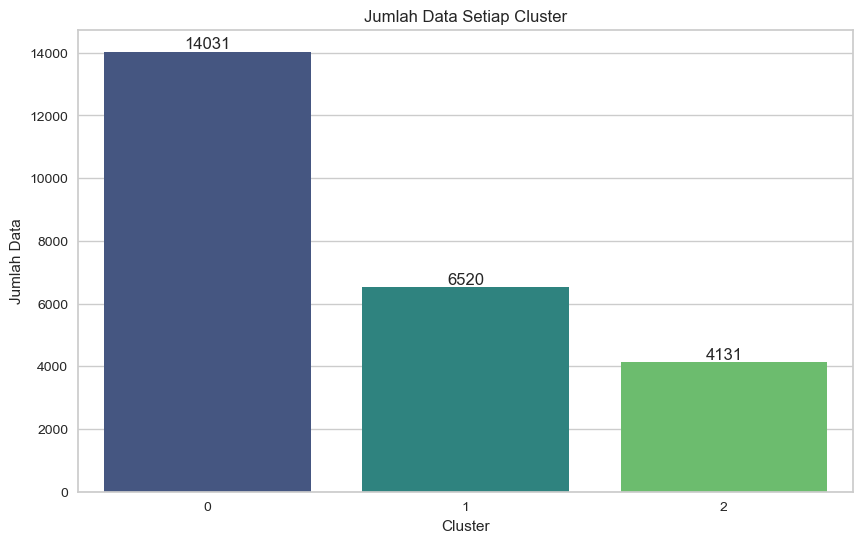

In [50]:
# Menghitung jumlah data di setiap cluster
cluster_counts = df_cluster['cluster'].value_counts()

# Membuat bar chart untuk jumlah data setiap cluster
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Jumlah Data Setiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')

# Menambahkan label jumlah data di atas setiap bar
for i, count in enumerate(cluster_counts.values):
    plt.text(i, count, str(count), ha='center', va='bottom')

plt.show()

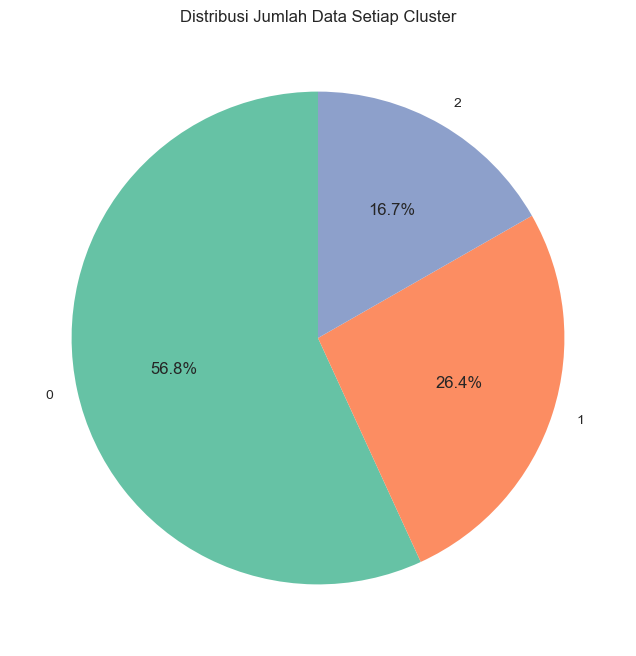

In [51]:
# Membuat pie chart untuk jumlah data setiap cluster
plt.figure(figsize=(8, 8))
cluster_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.title('Distribusi Jumlah Data Setiap Cluster')
plt.ylabel('')  # Menghapus label y
plt.show()

#### Visualisasi pesebaran setiap cluster pada peta

In [52]:
import plotly.express as px

fig = px.scatter_mapbox(df_cluster, 
                        lat="latitude",
                        lon="longitude",
                        color='cluster',  # cluster sebagai warna
                        zoom=3,
                        height=600,
                        title="Sebaran Cluster Gempa di Peta")

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

#### latitude statistik

In [53]:
df_cluster['latitude'].groupby(df_cluster['cluster']).describe().T

cluster,0,1,2
count,14031.000000,6520.000000,4131.000000
mean,4.663938,47.959645,16.015905
std,28.115362,13.042192,22.633672
min,-65.849700,-43.679200,-65.494800
25%,-17.676700,42.046925,17.571333
50%,2.611800,51.898150,18.749800
75%,28.981800,54.711500,31.633000
max,86.593900,72.104200,76.336500


#### longtitude statistik

In [54]:
df_cluster['longitude'].groupby(df_cluster['cluster']).describe().T

cluster,0,1,2
count,14031.000000,6520.000000,4131.000000
mean,41.982200,-126.456578,-36.641188
std,121.475091,85.539748,89.915016
min,-179.997500,-179.998700,-179.966100
25%,-69.136700,-166.879750,-71.568300
50%,102.601700,-155.300083,-66.843833
75%,140.546400,-117.735917,-27.151600
max,179.999400,179.991500,179.849900


#### depth statistik 

In [55]:
df_cluster['depth'].groupby(df_cluster['cluster']).describe().T

cluster,0,1,2
count,1.403100e+04,6520.000000,4131.000000
mean,9.071704e+01,33.234332,39.003673
std,1.422154e+02,40.362974,66.455273
min,-1.781408e-15,-3.370000,-2.130000
25%,1.000000e+01,8.379235,10.000000
50%,3.500000e+01,16.335500,15.000000
75%,1.031650e+02,35.000000,41.752000
max,6.812380e+02,338.797000,622.680000


#### mag statistik 

In [56]:
df_cluster['mag'].groupby(df_cluster['cluster']).describe().T

cluster,0,1,2
count,14031.000000,6520.000000,4131.000000
mean,4.424154,2.973043,3.990676
std,0.295958,0.327987,1.099605
min,3.100000,2.600000,2.600000
25%,4.200000,2.700000,2.980000
50%,4.400000,2.900000,3.730000
75%,4.600000,3.200000,5.000000
max,6.100000,5.700000,7.800000


#### magType statistik

In [57]:
df_cluster['magType'].groupby(df_cluster['cluster']).describe().T

cluster,0,1,2
count,14031,6520,4131
unique,1,1,13
top,mb,ml,md
freq,14031,6520,2117


In [58]:
# Melihat distribusi kategori(magType) per cluster
df_cluster.groupby('cluster')['magType'].value_counts(normalize=True)

cluster  magType   
0        mb            1.000000
1        ml            1.000000
2        md            0.512467
         mww           0.286855
         mwr           0.129267
         ml(texnet)    0.032438
         mw            0.020818
         mb_lg         0.014524
         mlr           0.000968
         mh            0.000726
         mwb           0.000726
         mlv           0.000484
         ms_vx         0.000242
         mwc           0.000242
         mwp           0.000242
Name: proportion, dtype: float64

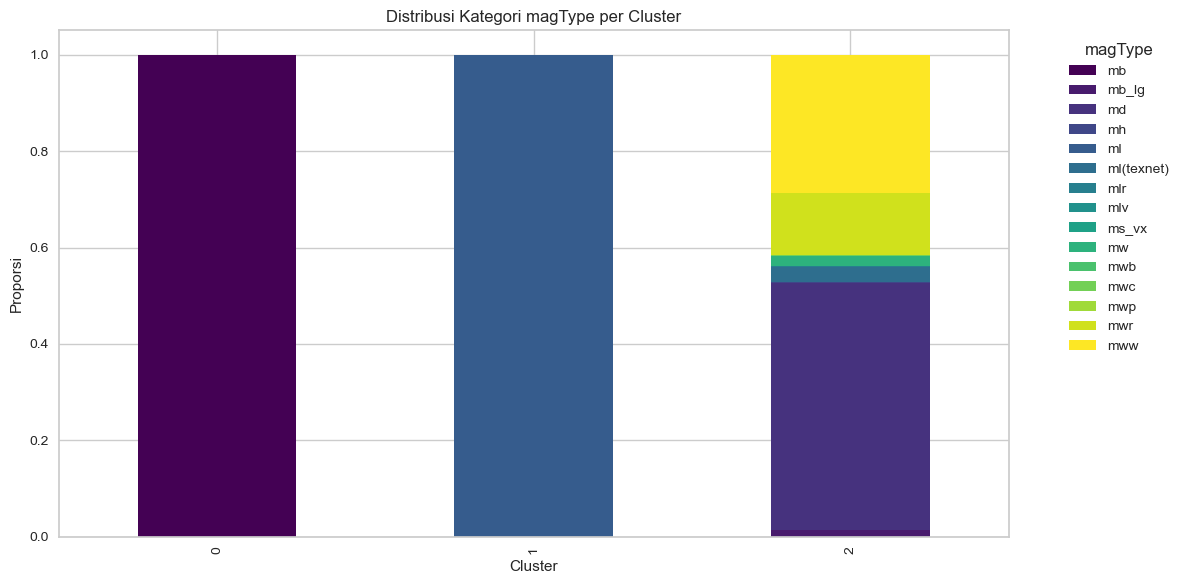

In [59]:
# # Membuat visualisasi distribusi kategori magType per cluster
magtype_distribution = df_cluster.groupby('cluster')['magType'].value_counts(normalize=True).unstack()

magtype_distribution.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Distribusi Kategori magType per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporsi')
plt.legend(title='magType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Analisis Karakteristik Cluster dari Model KMeans**

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

---

## **Cluster 0:**
- **Jumlah Data:** 14.031 (56.8%)
- **Rata-rata Magnitudo (mag):** 4.42  
- **Rentang Magnitudo:** 3.1 – 6.10  
- **Rata-rata Kedalaman (depth):** 90.72 km  
- **Rentang Kedalaman:** -1.78 – 681.23 km  
- **Jenis Magnitudo Dominan:** `mb` (100%)  

### **Analisis:**

Cluster ini merupakan kelompok terbesar yang mencakup lebih dari setengah dari total data. Karakteristik utamanya adalah magnitudo menengah (rata-rata 4.42) dengan rentang yang cukup luas, serta kedalaman gempa yang tinggi dengan rata-rata 90.72 km dan rentang kedalaman mencapai lebih dari 680 km. Dominasi jenis magnitudo `mb` menunjukkan bahwa metode pengukuran magnitudo yang digunakan adalah berdasarkan gelombang body (body wave), yang umum digunakan untuk gempa-gempa yang terjadi di kedalaman menengah hingga dalam.

Cluster ini dapat dikaitkan dengan aktivitas seismik di zona subduksi, di mana gempa sering terjadi pada kedalaman besar dan dengan magnitudo menengah. Persebaran spasial klaster ini yang luas mendukung analisis bahwa cluster ini mencerminkan **aktivitas gempa bumi global yang dominan terjadi di batas lempeng konvergen** seperti di wilayah Pasifik (Ring of Fire), yang sangat aktif secara seismik.

---

## **Cluster 1:**
- **Jumlah Data:** 6.520 (26.4%)  
- **Rata-rata Magnitudo (mag):** 2.97  
- **Rentang Magnitudo:** 2.6 – 5.7  
- **Rata-rata Kedalaman (depth):** 33.23 km  
- **Rentang Kedalaman:** -3.37 – 338.79 km  
- **Jenis Magnitudo Dominan:** `ml` (100%)  

### **Analisis:**

Cluster ini dicirikan oleh gempa-gempa dengan magnitudo kecil hingga sedang (rata-rata 2.97), dan terjadi di kedalaman yang relatif dangkal (rata-rata 33.23 km). Jenis magnitudo yang digunakan adalah `ml` (local magnitude), yang umum digunakan untuk mengukur gempa-gempa lokal dengan kekuatan kecil. Hal ini menunjukkan bahwa gempa pada klaster ini kemungkinan terjadi **dekat permukaan dan terlokalisasi di wilayah tertentu**, seperti patahan-patahan lokal atau wilayah aktivitas vulkanik rendah.

Dengan persebaran spasial yang lebih terbatas, cluster ini sangat mungkin mewakili **zona aktif lokal di wilayah Amerika Utara atau Eropa**, di mana sistem pemantauan gempa lokal lebih sensitif terhadap aktivitas mikro-seismik. Cluster ini menggambarkan **aktivitas gempa lokal atau regional yang lebih sering terjadi namun kurang destruktif dibandingkan dengan gempa pada cluster lainnya.**

---

## **Cluster 2:**
- **Jumlah Data:** 4.131 (16.7%)  
- **Rata-rata Magnitudo (mag):** 3.99  
- **Rentang Magnitudo:** 2.6 – 7.79  
- **Rata-rata Kedalaman (depth):** 39.00 km  
- **Rentang Kedalaman:** -2.13 – 622.67 km  
- **Jenis Magnitudo Dominan:** `md` (51.2%) diikuti dengan `mww` (28.7%)

### **Analisis:**

Cluster ini memiliki karakteristik unik dengan kombinasi magnitudo sedang (rata-rata 3.99) dan kedalaman yang juga berada di level menengah (rata-rata 39 km). Meskipun jumlah datanya paling sedikit, cluster ini memiliki **rentang magnitudo paling luas**, hingga mencapai 7.79, menunjukkan adanya gempa-gempa besar di dalam klaster ini.

Dominasi jenis magnitudo `md` (duration magnitude) yang sering digunakan untuk gempa kecil hingga menengah, dan `mww` (moment magnitude) untuk gempa besar dan lebih kompleks, menunjukkan bahwa klaster ini **menggabungkan berbagai tipe kejadian seismik**, mulai dari aktivitas mikro hingga gempa besar.

Persebaran spasial pada klaster ini mengarah pada wilayah **mid-ocean ridges atau zona divergen** seperti di Samudera Atlantik Tengah, serta beberapa aktivitas di zona transisional antara lempeng. Cluster ini mewakili **gempa-gempa di wilayah laut dalam atau zona sesar transform**, di mana jenis dan ukuran gempa bervariasi lebih bebas dibanding klaster lainnya.

---

## **Kesimpulan:**

Hasil klasterisasi berdasarkan magnitudo, kedalaman, dan jenis magnitudo menunjukkan pembagian yang logis dan informatif mengenai karakteristik aktivitas seismik global. Cluster 0 mencerminkan gempa subduksi besar dan dalam secara global, Cluster 1 menggambarkan aktivitas lokal dan dangkal dengan intensitas rendah, sedangkan Cluster 2 menunjukkan zona seismik dengan variasi besar dalam magnitudo dan kedalaman, termasuk gempa besar dengan kedalaman menengah. 

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [61]:
df_cluster.to_csv('hasil_clustering.csv', index=False)